In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow import keras
import cv2
from sklearn.model_selection import train_test_split

base = '/content/drive/MyDrive/KemikAI'

# Yeni multimodal modeli yükle
model = keras.models.load_model(f'{base}/models/kemikai_multimodal_best.keras')
print("✅ Model yüklendi!")

for i, inp in enumerate(model.inputs):
    print(f"Input {i}: {inp.name}, shape: {inp.shape}")

Mounted at /content/drive
✅ Model yüklendi!
Input 0: image_input, shape: (None, 224, 224, 3)
Input 1: tabular_input, shape: (None, 8)


In [2]:
from sklearn.preprocessing import StandardScaler

# Veriyi yükle
df = pd.read_csv('/content/drive/MyDrive/KemikAI/data/raw/RSNA_Annotations/RSNA_Annotations/BONEAGE/boneage_train.csv')
df['gender'] = df['Male'].apply(lambda x: 1 if x else 0)

# Sentetik klinik veri üret
def generate_synthetic_clinical_data(df):
    df = df.copy()
    age_y = df['Boneage'] / 12.0
    base_height = 70 + (age_y * 6)
    df['height_cm'] = np.random.normal(base_height, 5).clip(50, 200)
    base_weight = 10 + (age_y * 2.5)
    df['weight_kg'] = np.random.normal(base_weight, 3).clip(3, 120)
    df['mother_height'] = np.random.normal(162, 6, size=len(df)).clip(145, 185)
    df['father_height'] = np.random.normal(175, 7, size=len(df)).clip(160, 195)
    df['vit_d_deficiency'] = np.random.choice([0, 1], p=[0.8, 0.2], size=len(df))
    df['calcium_level'] = np.random.choice([0, 1, 2], p=[0.1, 0.8, 0.1], size=len(df))
    df['fracture_history'] = np.random.choice([0, 1], p=[0.85, 0.15], size=len(df))
    return df

df = generate_synthetic_clinical_data(df)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# Normalize et
continuous_cols = ['height_cm', 'weight_kg', 'mother_height', 'father_height']
categorical_cols = ['gender', 'vit_d_deficiency', 'calcium_level', 'fracture_history']
tabular_cols = continuous_cols + categorical_cols

scaler = StandardScaler()
train_df[continuous_cols] = scaler.fit_transform(train_df[continuous_cols])
val_df[continuous_cols] = scaler.transform(val_df[continuous_cols])

print(f"✅ Val set: {len(val_df)} görüntü")
print(df.head())

✅ Val set: 2523 görüntü
     ID   Male  Boneage  gender   height_cm  weight_kg  mother_height  \
0  1377  False      180       0  162.477028  47.888385     159.908655   
1  1378  False       12       0   64.510916  16.791348     161.121732   
2  1379  False       94       0  122.787581  26.522292     161.771207   
3  1380   True      120       1  123.618160  33.121520     148.448195   
4  1381  False       82       0  120.810449  29.279847     161.248428   

   father_height  vit_d_deficiency  calcium_level  fracture_history  
0     174.420071                 0              1                 0  
1     176.531066                 0              0                 0  
2     188.412523                 1              1                 0  
3     174.667826                 0              2                 0  
4     174.810044                 1              1                 0  


In [3]:
# Görüntüleri kopyala
import shutil
if not os.path.exists('/content/train_images'):
    print("Kopyalanıyor...")
    shutil.copytree('/content/drive/MyDrive/KemikAI/data/raw/RSNA_train/images', '/content/train_images')
    print("✅ Kopyalandı!")
else:
    print("✅ Zaten var!")

# Değerlendirme
preds, actuals = [], []

for _, row in val_df.iterrows():
    img_path = f'/content/train_images/{int(row.ID)}.png'
    if not os.path.exists(img_path):
        continue

    # Görüntü
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.float32)
    img_batch = tf.expand_dims(img, axis=0)

    # Tabular
    tabular = row[tabular_cols].values.astype(np.float32)
    tabular_batch = np.expand_dims(tabular, axis=0)

    pred = model.predict(
        {'image_input': img_batch, 'tabular_input': tabular_batch},
        verbose=0
    )[0][0]
    preds.append(pred)
    actuals.append(row.Boneage)

mae = np.mean(np.abs(np.array(preds) - np.array(actuals)))
print(f"✅ Değerlendirilen görüntü: {len(preds)}")
print(f"✅ Val MAE: {mae:.2f} ay")
print(f"✅ Val MAE: {mae/12:.2f} yıl")

Kopyalanıyor...
✅ Kopyalandı!
✅ Değerlendirilen görüntü: 2377
✅ Val MAE: 5.59 ay
✅ Val MAE: 0.47 yıl


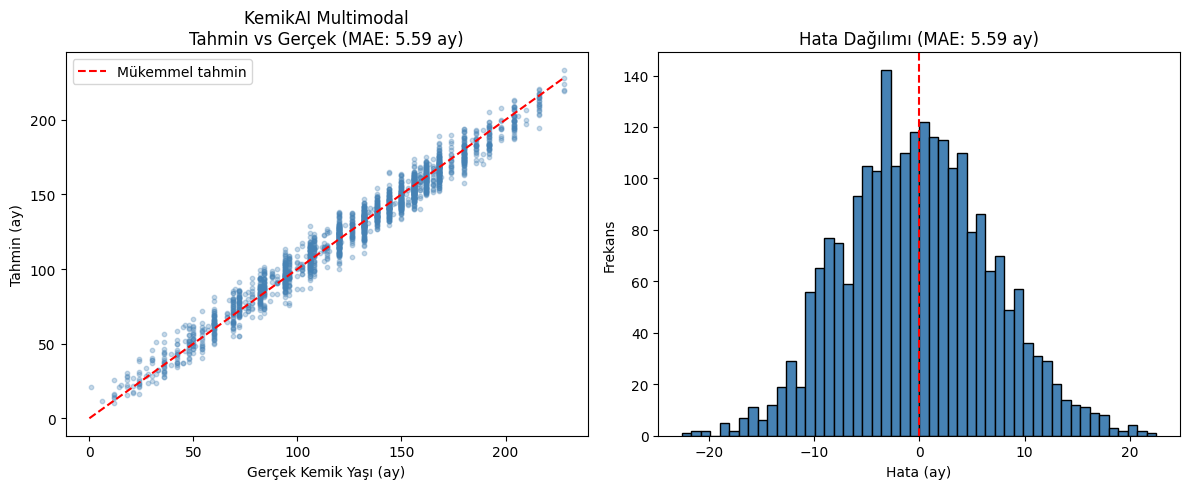

✅ Grafik kaydedildi!


In [4]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(actuals, preds, alpha=0.3, s=10, color='steelblue')
plt.plot([0, 228], [0, 228], 'r--', label='Mükemmel tahmin')
plt.xlabel('Gerçek Kemik Yaşı (ay)')
plt.ylabel('Tahmin (ay)')
plt.title(f'KemikAI Multimodal\nTahmin vs Gerçek (MAE: {mae:.2f} ay)')
plt.legend()

plt.subplot(1, 2, 2)
errors = np.array(preds) - np.array(actuals)
plt.hist(errors, bins=50, color='steelblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Hata (ay)')
plt.ylabel('Frekans')
plt.title(f'Hata Dağılımı (MAE: {mae:.2f} ay)')

plt.tight_layout()
plt.savefig(f'{base}/outputs/plots/evaluation_multimodal.png')
plt.show()
print("✅ Grafik kaydedildi!")

In [ ]:
# İlk 5 tahmini göster
for i, (pred, actual) in enumerate(zip(preds[:5], actuals[:5])):
    print(f"Tahmin: {pred:.1f} ay ({pred/12:.1f} yıl) | Gerçek: {actual} ay ({actual/12:.1f} yıl)")

Tahmin: 18.1 ay (1.5 yıl) | Gerçek: 94 ay (7.8 yıl)
Tahmin: 9.7 ay (0.8 yıl) | Gerçek: 120 ay (10.0 yıl)
Tahmin: 7.3 ay (0.6 yıl) | Gerçek: 180 ay (15.0 yıl)
Tahmin: 11.8 ay (1.0 yıl) | Gerçek: 120 ay (10.0 yıl)
Tahmin: 8.6 ay (0.7 yıl) | Gerçek: 84 ay (7.0 yıl)


In [ ]:
preds, actuals = [], []

for _, row in val_df.iterrows():
    img_path = f'/content/train_images/{int(row.ID)}.png'

    if not tf.io.gfile.exists(img_path):
        continue

    img = preprocess_image(img_path)
    img_batch = tf.expand_dims(img, axis=0)
    gender_batch = tf.convert_to_tensor([[float(row.gender)]], dtype=tf.float32)

    pred = model.predict([img_batch, gender_batch], verbose=0)[0][0]
    preds.append(pred)
    actuals.append(row.Boneage)

mae = np.mean(np.abs(np.array(preds) - np.array(actuals)))
print(f"✅ Değerlendirilen görüntü: {len(preds)}")
print(f"✅ Val MAE: {mae:.2f} ay")
print(f"✅ Val MAE: {mae/12:.2f} yıl")

✅ Değerlendirilen görüntü: 2377
✅ Val MAE: 8.33 ay
✅ Val MAE: 0.69 yıl


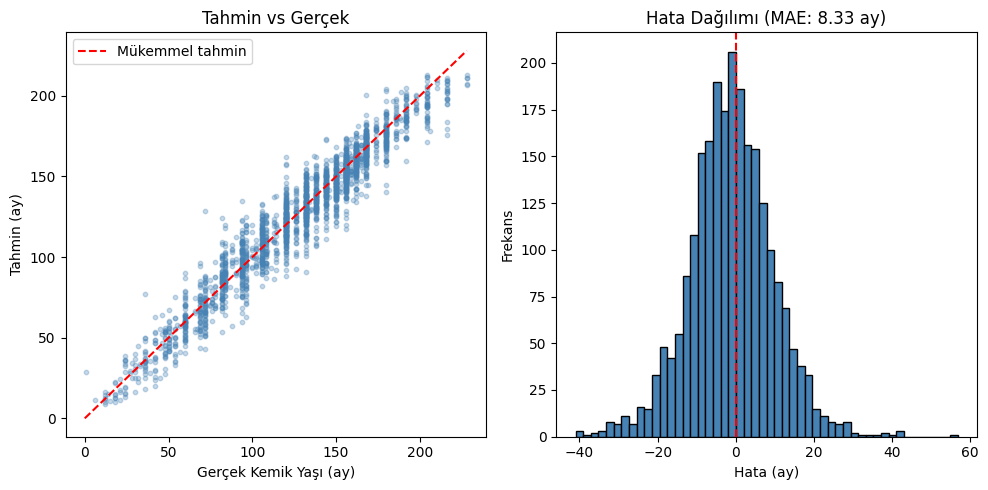

✅ Grafik kaydedildi!


In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(actuals, preds, alpha=0.3, s=10, color='steelblue')
plt.plot([0, 228], [0, 228], 'r--', label='Mükemmel tahmin')
plt.xlabel('Gerçek Kemik Yaşı (ay)')
plt.ylabel('Tahmin (ay)')
plt.title('Tahmin vs Gerçek')
plt.legend()

plt.subplot(1, 2, 2)
errors = np.array(preds) - np.array(actuals)
plt.hist(errors, bins=50, color='steelblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel('Hata (ay)')
plt.ylabel('Frekans')
plt.title(f'Hata Dağılımı (MAE: {mae:.2f} ay)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/KemikAI/outputs/plots/evaluation.png')
plt.show()
print("✅ Grafik kaydedildi!")